# Predicting the outcome of matches using odds data
- Assumption is that the odds data are pre game odds
- The essentials is that only prematch stats are usefull in predicting the outcome not the match statistics of precious games.



In [148]:
import pandas as pd


In [149]:
# Load the dataset
df = pd.read_csv('data/merged_data.csv')
df 

/tmp/ipykernel_23797/439636466.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/merged_data.csv')


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,Attendance,HHW,AHW,HO,AO,HBP,ABP,SYH,SYD,SYA
0,E0,2024-08-16,20:00:00,Man United,Fulham,1.0,0.0,H,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,2024-08-17,12:30:00,Ipswich,Liverpool,0.0,2.0,A,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,2024-08-17,15:00:00,Arsenal,Wolves,2.0,0.0,H,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,2024-08-17,15:00:00,Everton,Brighton,0.0,3.0,A,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,2024-08-17,15:00:00,Newcastle,Southampton,1.0,0.0,H,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [150]:
columns = df.columns
columns.tolist()



['Div',
 'Date',
 'Time',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR',
 'HTHG',
 'HTAG',
 'HTR',
 'Referee',
 'HS',
 'AS',
 'HST',
 'AST',
 'HF',
 'AF',
 'HC',
 'AC',
 'HY',
 'AY',
 'HR',
 'AR',
 'B365H',
 'B365D',
 'B365A',
 'BWH',
 'BWD',
 'BWA',
 'BFH',
 'BFD',
 'BFA',
 'PSH',
 'PSD',
 'PSA',
 'WHH',
 'WHD',
 'WHA',
 '1XBH',
 '1XBD',
 '1XBA',
 'MaxH',
 'MaxD',
 'MaxA',
 'AvgH',
 'AvgD',
 'AvgA',
 'BFEH',
 'BFED',
 'BFEA',
 'B365>2.5',
 'B365<2.5',
 'P>2.5',
 'P<2.5',
 'Max>2.5',
 'Max<2.5',
 'Avg>2.5',
 'Avg<2.5',
 'BFE>2.5',
 'BFE<2.5',
 'AHh',
 'B365AHH',
 'B365AHA',
 'PAHH',
 'PAHA',
 'MaxAHH',
 'MaxAHA',
 'AvgAHH',
 'AvgAHA',
 'BFEAHH',
 'BFEAHA',
 'B365CH',
 'B365CD',
 'B365CA',
 'BWCH',
 'BWCD',
 'BWCA',
 'BFCH',
 'BFCD',
 'BFCA',
 'PSCH',
 'PSCD',
 'PSCA',
 'WHCH',
 'WHCD',
 'WHCA',
 '1XBCH',
 '1XBCD',
 '1XBCA',
 'MaxCH',
 'MaxCD',
 'MaxCA',
 'AvgCH',
 'AvgCD',
 'AvgCA',
 'BFECH',
 'BFECD',
 'BFECA',
 'B365C>2.5',
 'B365C<2.5',
 'PC>2.5',
 'PC<2.5',
 'MaxC>2.5',
 'MaxC

In [151]:
df.isnull().sum()

Div          172
Date         172
Time        7392
HomeTeam     172
AwayTeam     172
            ... 
HBP         8582
ABP         8582
SYH         8969
SYD         8969
SYA         8969
Length: 187, dtype: int64

In [152]:
columns_to_keep = ['Div','Date','HomeTeam','AwayTeam','FTR','WHH','WHD','WHA']
df = df[columns_to_keep]
df.head()

,Div,Date,HomeTeam,AwayTeam,FTR,WHH,WHD,WHA
0,E0,2024-08-16,Man United,Fulham,H,1.65,4.2,5.00
1,E0,2024-08-17,Ipswich,Liverpool,A,8.50,5.5,1.33
2,E0,2024-08-17,Arsenal,Wolves,H,1.18,7.0,17.00
3,E0,2024-08-17,Everton,Brighton,A,2.60,3.5,2.70
4,E0,2024-08-17,Newcastle,Southampton,H,1.35,5.5,8.00


In [153]:
df.isnull().sum()

Div         172
Date        172
HomeTeam    172
AwayTeam    172
FTR         172
WHH         666
WHD         666
WHA         666
dtype: int64

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9342 entries, 0 to 9341
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Div       9170 non-null   object 
 1   Date      9170 non-null   object 
 2   HomeTeam  9170 non-null   object 
 3   AwayTeam  9170 non-null   object 
 4   FTR       9170 non-null   object 
 5   WHH       8676 non-null   float64
 6   WHD       8676 non-null   float64
 7   WHA       8676 non-null   float64
dtypes: float64(3), object(5)
memory usage: 584.0+ KB


In [155]:
df.isnull().sum()


Div         172
Date        172
HomeTeam    172
AwayTeam    172
FTR         172
WHH         666
WHD         666
WHA         666
dtype: int64

In [156]:
# Drop rows with missing data across all columns
df = df.dropna()
df

,Div,Date,HomeTeam,AwayTeam,FTR,WHH,WHD,WHA
0,E0,2024-08-16,Man United,Fulham,H,1.65,4.2,5.00
1,E0,2024-08-17,Ipswich,Liverpool,A,8.50,5.5,1.33
2,E0,2024-08-17,Arsenal,Wolves,H,1.18,7.0,17.00
3,E0,2024-08-17,Everton,Brighton,A,2.60,3.5,2.70
4,E0,2024-08-17,Newcastle,Southampton,H,1.35,5.5,8.00
...,...,...,...,...,...,...,...,...
8785,E0,2001-05-19,Man City,Chelsea,A,4.00,3.1,1.80
8786,E0,2001-05-19,Middlesbrough,West Ham,H,1.83,3.4,3.50
8787,E0,2001-05-19,Newcastle,Aston Villa,H,2.25,3.4,2.60
8788,E0,2001-05-19,Southampton,Arsenal,H,2.62,3.5,2.20


In [157]:
df.isnull().sum()

Div         0
Date        0
HomeTeam    0
AwayTeam    0
FTR         0
WHH         0
WHD         0
WHA         0
dtype: int64

In [158]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8676 entries, 0 to 8789
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Div       8676 non-null   object 
 1   Date      8676 non-null   object 
 2   HomeTeam  8676 non-null   object 
 3   AwayTeam  8676 non-null   object 
 4   FTR       8676 non-null   object 
 5   WHH       8676 non-null   float64
 6   WHD       8676 non-null   float64
 7   WHA       8676 non-null   float64
dtypes: float64(3), object(5)
memory usage: 610.0+ KB


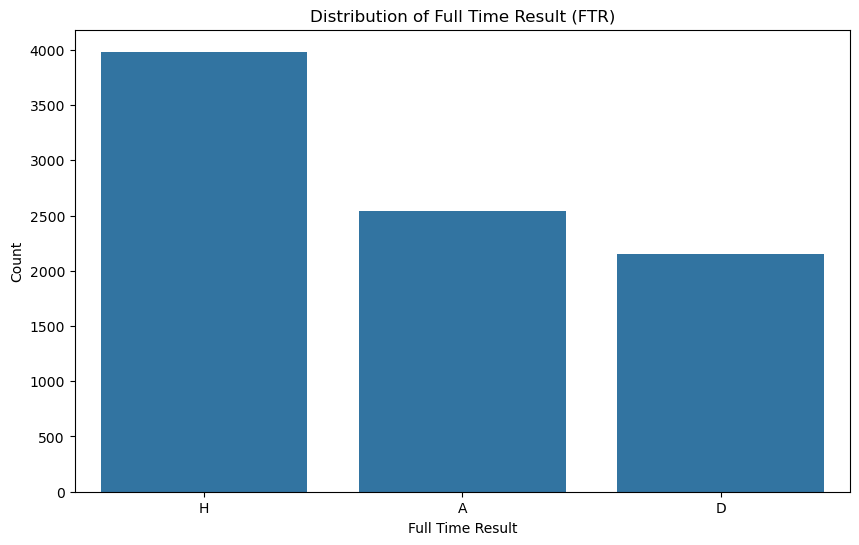

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt
# Visualize the distribution of the 'FTR' column
plt.figure(figsize=(10, 6))
sns.countplot(x='FTR', data=df)
plt.title('Distribution of Full Time Result (FTR)')
plt.xlabel('Full Time Result')
plt.ylabel('Count')
plt.show()

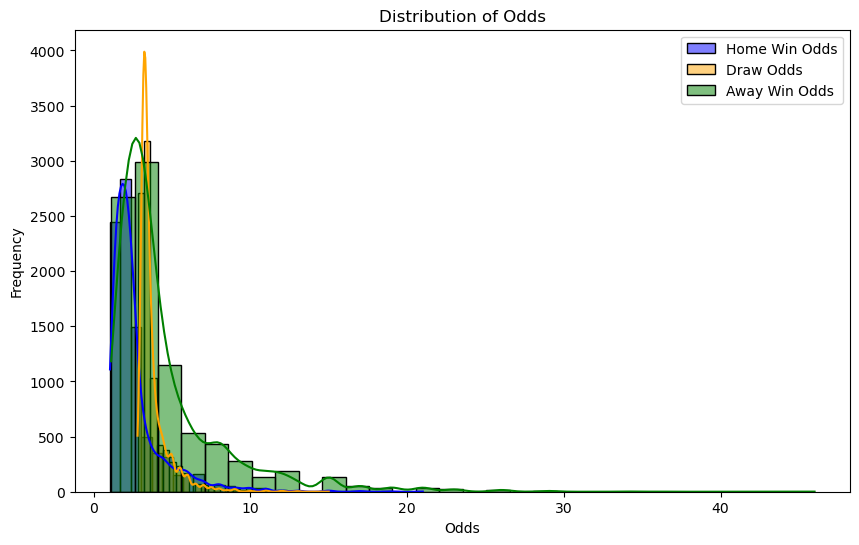

In [160]:
# distrbution of odds
plt.figure(figsize=(10, 6))
sns.histplot(df['WHH'], bins=30, kde=True, color='blue', label='Home Win Odds')
sns.histplot(df['WHD'], bins=30, kde=True, color='orange', label='Draw Odds')
sns.histplot(df['WHA'], bins=30, kde=True, color='green', label='Away Win Odds')
plt.title('Distribution of Odds')
plt.xlabel('Odds')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [161]:
# team with the highest win rate
home_win_rate = df[df['FTR'] == 'H'].groupby('HomeTeam').size() / df.groupby('HomeTeam').size()
away_win_rate = df[df['FTR'] == 'A'].groupby('AwayTeam').size() / df.groupby('AwayTeam').size()
draw_rate = df[df['FTR'] == 'D'].groupby('HomeTeam').size() / df.groupby('HomeTeam').size() 
home_win_rate = home_win_rate.reset_index(name='Home Win Rate')
away_win_rate = away_win_rate.reset_index(name='Away Win Rate')
draw_rate = draw_rate.reset_index(name='Draw Rate') 
home_win_rate.accending = home_win_rate.sort_values(by='Home Win Rate', ascending=False)
away_win_rate.accending = away_win_rate.sort_values(by='Away Win Rate', ascending=False)
draw_rate.accending = draw_rate.sort_values(by='Draw Rate', ascending=False)
home_win_rate.head(10), away_win_rate.head(10), draw_rate.head(10)

/tmp/ipykernel_23797/649123637.py:8: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  home_win_rate.accending = home_win_rate.sort_values(by='Home Win Rate', ascending=False)
/tmp/ipykernel_23797/649123637.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  away_win_rate.accending = away_win_rate.sort_values(by='Away Win Rate', ascending=False)
/tmp/ipykernel_23797/649123637.py:10: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  draw_rate.accending = draw_rate.sort_values(by='Draw Rate', ascending=False)


(      HomeTeam  Home Win Rate
 0      Arsenal       0.678241
 1  Aston Villa       0.395225
 2   Birmingham       0.375000
 3    Blackburn       0.406863
 4    Blackpool       0.263158
 5       Bolton       0.394089
 6  Bournemouth       0.348148
 7     Bradford       0.210526
 8    Brentford       0.406780
 9     Brighton       0.338235,
       AwayTeam  Away Win Rate
 0      Arsenal       0.467890
 1  Aston Villa       0.275862
 2   Birmingham       0.173228
 3    Blackburn       0.251232
 4    Blackpool       0.263158
 5       Bolton       0.250000
 6  Bournemouth       0.250000
 7     Bradford       0.052632
 8    Brentford       0.266667
 9     Brighton       0.251852,
       HomeTeam  Draw Rate
 0      Arsenal   0.199074
 1  Aston Villa   0.286472
 2   Birmingham   0.351562
 3    Blackburn   0.284314
 4    Blackpool   0.263158
 5       Bolton   0.300493
 6  Bournemouth   0.266667
 7     Bradford   0.368421
 8    Brentford   0.288136
 9     Brighton   0.352941)

/tmp/ipykernel_23797/3506300518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HomeTeam', y='Home Win Rate', data=home_win_rate.accending.head(10), palette='viridis')


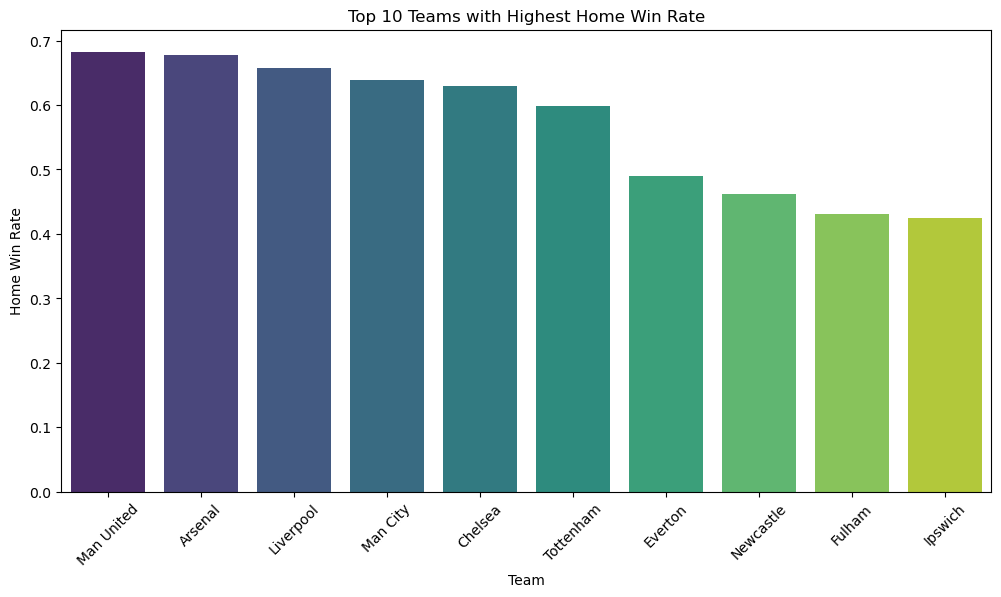

In [162]:
# plot the top 10 teams with the highest win rate
plt.figure(figsize=(12, 6))
sns.barplot(x='HomeTeam', y='Home Win Rate', data=home_win_rate.accending.head(10), palette='viridis')
plt.title('Top 10 Teams with Highest Home Win Rate')
plt.xlabel('Team')
plt.ylabel('Home Win Rate')
plt.xticks(rotation=45)
plt.show()

In [163]:
# win rate at home using the odds
home_win_rate_odds = df[df['FTR'] == 'H'].groupby('HomeTeam')['WHH'].mean() / df.groupby('HomeTeam')['WHH'].mean()
away_win_rate_odds = df[df['FTR'] == 'A'].groupby('AwayTeam')['WHA'].mean() / df.groupby('AwayTeam')['WHA'].mean()
draw_rate_odds = df[df['FTR'] == 'D'].groupby('HomeTeam')['WHD'].mean() / df.groupby('HomeTeam')['WHD'].mean()
home_win_rate_odds = home_win_rate_odds.reset_index(name='Home Win Rate Odds')
away_win_rate_odds = away_win_rate_odds.reset_index(name='Away Win Rate Odds')
draw_rate_odds = draw_rate_odds.reset_index(name='Draw Rate Odds')
home_win_rate_odds.accending = home_win_rate_odds.sort_values(by='Home Win Rate Odds', ascending=False)
away_win_rate_odds.accending = away_win_rate_odds.sort_values(by='Away Win Rate Odds', ascending=False)
draw_rate_odds.accending = draw_rate_odds.sort_values(by='Draw Rate Odds', ascending=False)
home_win_rate_odds.head(10), away_win_rate_odds.head(10), draw_rate_odds.head(10)

/tmp/ipykernel_23797/544161853.py:8: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  home_win_rate_odds.accending = home_win_rate_odds.sort_values(by='Home Win Rate Odds', ascending=False)
/tmp/ipykernel_23797/544161853.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  away_win_rate_odds.accending = away_win_rate_odds.sort_values(by='Away Win Rate Odds', ascending=False)
/tmp/ipykernel_23797/544161853.py:10: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  draw_rate_odds.accending = draw_rate_odds.sort_values(by='Draw Rate Odds', ascending=False)


(      HomeTeam  Home Win Rate Odds
 0      Arsenal            0.912087
 1  Aston Villa            0.792280
 2   Birmingham            0.818254
 3    Blackburn            0.835126
 4    Blackpool            0.773478
 5       Bolton            0.846981
 6  Bournemouth            0.805710
 7     Bradford            0.923753
 8    Brentford            0.775783
 9     Brighton            0.810009,
       AwayTeam  Away Win Rate Odds
 0      Arsenal            0.829341
 1  Aston Villa            0.760625
 2   Birmingham            0.708333
 3    Blackburn            0.791165
 4    Blackpool            0.881954
 5       Bolton            0.749793
 6  Bournemouth            0.624771
 7     Bradford            1.160896
 8    Brentford            0.940924
 9     Brighton            0.620944,
       HomeTeam  Draw Rate Odds
 0      Arsenal        0.910405
 1  Aston Villa        0.978295
 2   Birmingham        1.020263
 3    Blackburn        1.005478
 4    Blackpool        0.928161
 5       Bolto

/tmp/ipykernel_23797/2411211333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HomeTeam', y='Home Win Rate Odds', data=home_win_rate_odds.accending.head(10), palette='viridis')


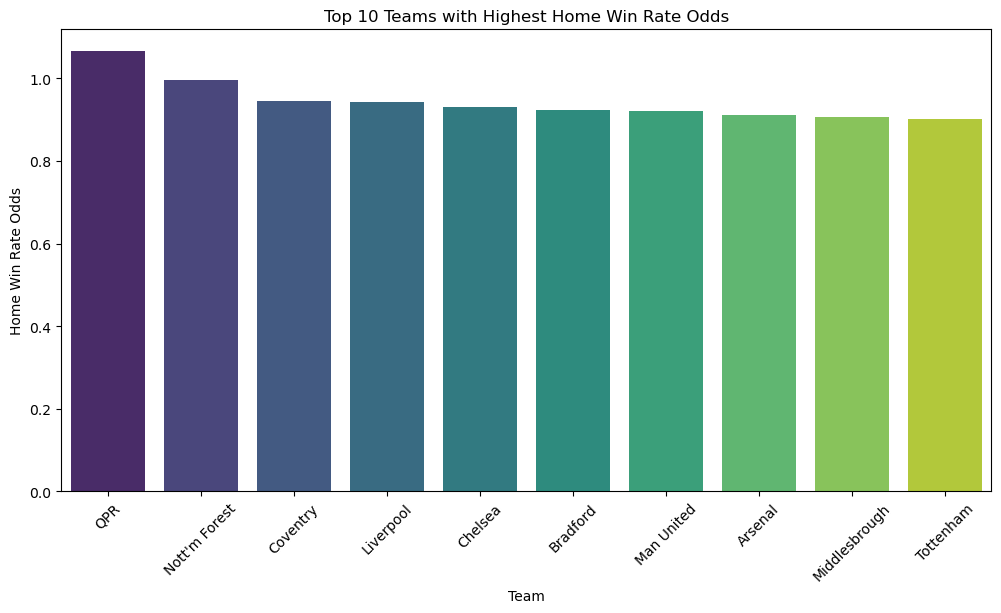

In [164]:
# plotting the win rates using the odds
plt.figure(figsize=(12, 6))
sns.barplot(x='HomeTeam', y='Home Win Rate Odds', data=home_win_rate_odds.accending.head(10), palette='viridis')
plt.title('Top 10 Teams with Highest Home Win Rate Odds')
plt.xlabel('Team')
plt.ylabel('Home Win Rate Odds')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_23797/2809222859.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HomeTeam', y='Home Win Rate Odds', data=home_win_rate_odds.accending.head(10), palette='viridis')


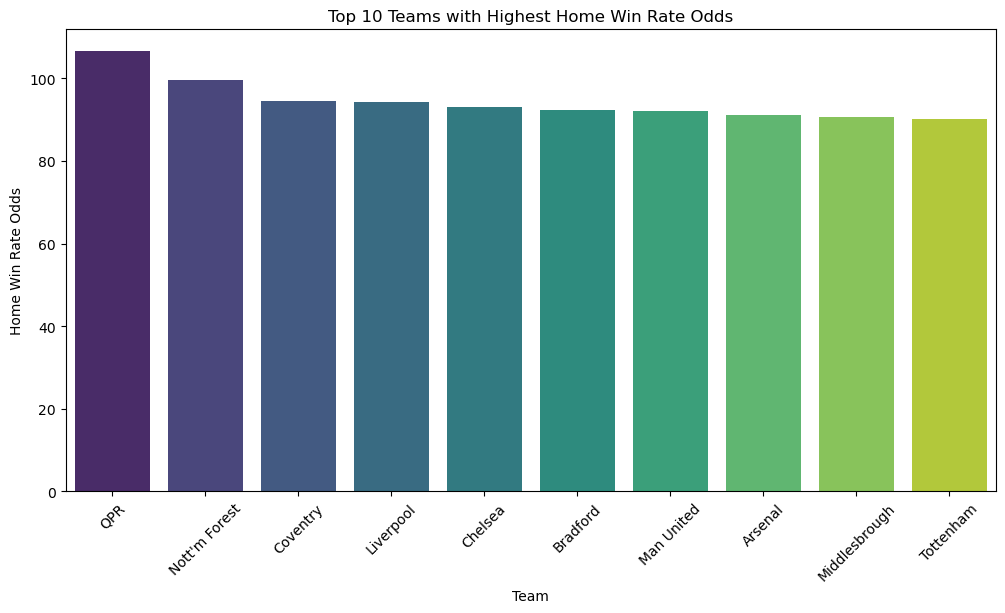

In [165]:
# show what percetage of the odds is the win rate
home_win_rate_odds.accending['Home Win Rate Odds'] = home_win_rate_odds.accending['Home Win Rate Odds'] * 100
away_win_rate_odds.accending['Away Win Rate Odds'] = away_win_rate_odds.accending['Away Win Rate Odds'] * 100
draw_rate_odds.accending['Draw Rate Odds'] = draw_rate_odds.accending['Draw Rate Odds'] * 100

# plot the top 10 teams with the highest win rate that match the odds
plt.figure(figsize=(12, 6))
sns.barplot(x='HomeTeam', y='Home Win Rate Odds', data=home_win_rate_odds.accending.head(10), palette='viridis')
plt.title('Top 10 Teams with Highest Home Win Rate Odds')
plt.xlabel('Team')
plt.ylabel('Home Win Rate Odds')
plt.xticks(rotation=45)
plt.show()

In [166]:
# encode FTR as numerical values
ftr_mapping = {'H': 0, 'D': 1, 'A': 2}
df['FTR'] = df['FTR'].map(ftr_mapping)

In [167]:
df

,Div,Date,HomeTeam,AwayTeam,FTR,WHH,WHD,WHA
0,E0,2024-08-16,Man United,Fulham,0,1.65,4.2,5.00
1,E0,2024-08-17,Ipswich,Liverpool,2,8.50,5.5,1.33
2,E0,2024-08-17,Arsenal,Wolves,0,1.18,7.0,17.00
3,E0,2024-08-17,Everton,Brighton,2,2.60,3.5,2.70
4,E0,2024-08-17,Newcastle,Southampton,0,1.35,5.5,8.00
...,...,...,...,...,...,...,...,...
8785,E0,2001-05-19,Man City,Chelsea,2,4.00,3.1,1.80
8786,E0,2001-05-19,Middlesbrough,West Ham,0,1.83,3.4,3.50
8787,E0,2001-05-19,Newcastle,Aston Villa,0,2.25,3.4,2.60
8788,E0,2001-05-19,Southampton,Arsenal,0,2.62,3.5,2.20


# PREPARE THE DATA FOR MODELING

In [168]:
# PREPARE THE DATA FOR MODELING

# 1. Convert categorical team variables to numerical using one-hot encoding
team_features = pd.get_dummies(df[['HomeTeam', 'AwayTeam']], prefix=['Home', 'Away'])

# 2. Combine odds features with encoded team features
features = ['WHH', 'WHD', 'WHA']
X = pd.concat([df[features], team_features], axis=1)
target = 'FTR'
y = df[target]

# 3. Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=42,
    stratify=y  # Ensures balanced distribution of outcomes
)

# 4. Scale the odds features while keeping team encodings binary
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
odds_columns = ['WHH', 'WHD', 'WHA']
X_train[odds_columns] = scaler.fit_transform(X_train[odds_columns])
X_test[odds_columns] = scaler.transform(X_test[odds_columns])


## XGBOOST

In [174]:
# use XGboost as the method of training the model
import xgboost as xgb
model = xgb.XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=3,  # Three classes: Home Win, Draw, Away Win
    eval_metric='mlogloss',  # Logarithmic loss for multi-class classification
    use_label_encoder=False,  # Avoid warning about label encoder
    random_state=42,  # For reproducibility
    n_estimators=100,  # Number of trees
    max_depth=6,  # Depth of each tree
    learning_rate=0.1,  # Step size shrinkage
    subsample=0.8,  # Fraction of samples to use for each tree
    colsample_bytree=0.8,  # Fraction of features to use for each tree
)
model.fit(X_train, y_train)


/home/sirian/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [12:13:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=3, ...)

### Model Evaluation

In [175]:
# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Home Win', 'Draw', 'Away Win']))


Model Accuracy: 0.54
Classification Report:
              precision    recall  f1-score   support

    Home Win       0.57      0.81      0.67      1195
        Draw       0.34      0.08      0.13       644
    Away Win       0.52      0.51      0.51       764

    accuracy                           0.54      2603
   macro avg       0.48      0.47      0.44      2603
weighted avg       0.50      0.54      0.49      2603



 - The accuracy of XGboost is 54% which is good for this model.

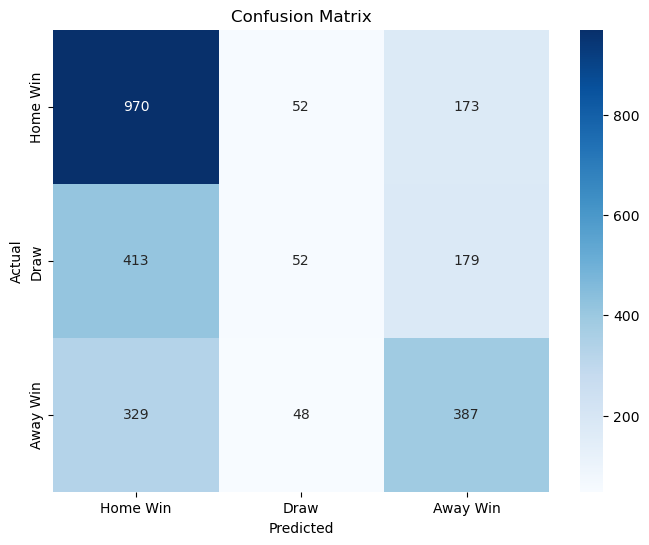

<Figure size 640x480 with 0 Axes>

In [176]:
# create a confusion matrix image
import seaborn as sns
import matplotlib.pyplot as plt
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Home Win', 'Draw', 'Away Win'],
            yticklabels=['Home Win', 'Draw', 'Away Win'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
# save the confusion matrix as an image
plt.savefig('confusion_matrix_XG.png')

#### Row by Row Analysis (Actual Results)
Row 1 - Actual Home Wins:
 - 970 correctly predicted as Home Wins
 - 52 incorrectly predicted as Draws
 - 173 incorrectly predicted as Away Wins

Row 2 - Actual Draws:
 - 413 incorrectly predicted as Home Wins
 - 52 correctly predicted as Draws
 - 179 incorrectly predicted as Away Wins

Row 3 - Actual Away Wins:
 - 329 incorrectly predicted as Home Wins
 - 48 incorrectly predicted as Draws
 - 387 correctly predicted as Away Wins

Key Insights:
1. Best Prediction: Home wins (970 correct)
2. Weakest Prediction: Draws (only 52 correct)
3. Model Bias: Tends to over-predict home wins
4. Total Correct: 970 + 52 + 387 = 1,409 correct predictions
5. Accuracy: 54% (as previously noted)

This suggests the model is better at predicting extreme outcomes (home/away wins) than draws, which is common in football prediction models.

## Neural Networks

In [177]:
# use neural networks as the method of training the model
from sklearn.neural_network import MLPClassifier
nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # Two hidden layers with 100 and 50 neurons
    activation='relu',  # ReLU activation function
    solver='adam',  # Adam optimizer
    max_iter=500,  # Maximum number of iterations
    random_state=42,  # For reproducibility
)
nn_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)


Neural Network Model Performance:
Model Accuracy: 0.44

Classification Report:
              precision    recall  f1-score   support

    Home Win       0.54      0.56      0.55      1195
        Draw       0.27      0.27      0.27       644
    Away Win       0.42      0.40      0.41       764

    accuracy                           0.44      2603
   macro avg       0.41      0.41      0.41      2603
weighted avg       0.44      0.44      0.44      2603



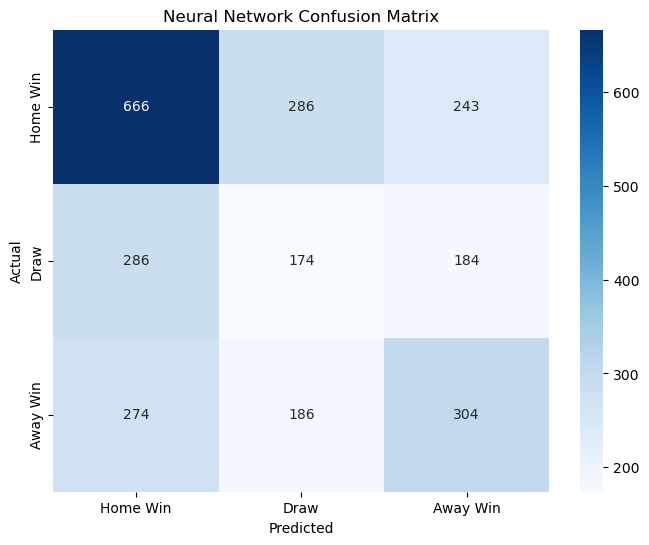


Model Comparison:
XGBoost Accuracy: 0.54
Neural Network Accuracy: 0.44


<Figure size 640x480 with 0 Axes>

In [178]:
# 1. Evaluate neural network model performance
y_pred_nn = nn_model.predict(X_test)
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print("\nNeural Network Model Performance:")
print(f"Model Accuracy: {accuracy_nn:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=['Home Win', 'Draw', 'Away Win']))

# 2. Create confusion matrix for neural network
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Home Win', 'Draw', 'Away Win'],
            yticklabels=['Home Win', 'Draw', 'Away Win'])
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
plt.savefig('confusion_matrix_NN.png')

# 3. Compare model performances
print("\nModel Comparison:")
print(f"XGBoost Accuracy: {accuracy:.2f}")
print(f"Neural Network Accuracy: {accuracy_nn:.2f}")